# Other Plots Examples

This notebook demonstrates the usage of the OtherPlots class methods for various machine learning visualization tasks. The OtherPlots class provides comprehensive tools for analyzing clustering, dimensionality reduction, anomaly detection, cross-validation, and feature selection.

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import (
    make_classification,
    make_regression,
    make_blobs,
    load_wine,
    load_diabetes,
    load_iris,
)
from sklearn.model_selection import cross_val_score, KFold, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA, FactorAnalysis
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage
from kvbiii_plots.ml.other_plots import OtherPlots

%matplotlib inline

In [2]:
other_plots = OtherPlots()

np.random.seed(42)

print("OtherPlots initialized successfully!")
print("Available methods:")
methods = [
    method
    for method in dir(other_plots)
    if not method.startswith("_") and callable(getattr(other_plots, method))
]
for method in methods:
    print(f"  - {method}")

OtherPlots initialized successfully!
Available methods:
  - add_quantile_annotations
  - anova_comparison_plot
  - apply_default_layout
  - calculate_dynamic_dimensions
  - check_2d_data
  - check_data
  - cluster_visualization_plot
  - create_subplot_layout
  - cross_validation_components_plot
  - cross_validation_split_plot
  - dendrogram_plot
  - difference_curve
  - elbow_plot
  - feature_importance_plot
  - feature_ranking_scatter_plot
  - filter_nan_indices
  - gap_statistic_plot
  - isolation_forest_plot
  - k_distance_plot
  - lda_separation_plot
  - local_outlier_factor_plot
  - mahalanobis_anomaly_plot
  - mahalanobis_distance_plot
  - normalized_elbow_plot
  - pca_eigenvectors_plot
  - pca_explained_variance_plot
  - pca_inverse_transform_plot
  - plot_metric_change_vs_features_removed
  - scree_plot
  - silhouette_analysis_plot
  - silhouette_detailed_plot


## Prepare Datasets

We'll create different datasets to demonstrate various OtherPlots capabilities:
1. Clustering datasets with different structures
2. Classification datasets for dimensionality reduction
3. Regression datasets for feature selection
4. Anomaly detection scenarios

In [3]:
print("Preparing datasets...")

X_clusters, y_clusters = make_blobs(
    n_samples=300, centers=4, n_features=2, random_state=42, cluster_std=1.5
)

X_clusters_hd, _ = make_blobs(
    n_samples=500, centers=5, n_features=10, random_state=42, cluster_std=2.0
)

X_class_synthetic, y_class_synthetic = make_classification(
    n_samples=800, n_features=15, n_informative=8, n_redundant=3, n_classes=3, random_state=42
)

wine_data = load_wine()
X_wine, y_wine = wine_data.data, wine_data.target

iris_data = load_iris()
X_iris, y_iris = iris_data.data, iris_data.target

diabetes_data = load_diabetes()
X_diabetes, y_diabetes = diabetes_data.data, diabetes_data.target

X_reg_synthetic, y_reg_synthetic = make_regression(
    n_samples=1000, n_features=20, noise=0.1, random_state=42
)

X_anomaly = np.random.multivariate_normal(mean=[0, 0], cov=[[1, 0.5], [0.5, 1]], size=200)
outliers = np.random.multivariate_normal(mean=[5, 5], cov=[[0.5, 0], [0, 0.5]], size=20)
X_anomaly_with_outliers = np.vstack([X_anomaly, outliers])

print(f"Clustering data (2D): {X_clusters.shape}")
print(f"Clustering data (high-dim): {X_clusters_hd.shape}")
print(f"Classification data: {X_class_synthetic.shape}")
print(f"Wine dataset: {X_wine.shape}")
print(f"Iris dataset: {X_iris.shape}")
print(f"Diabetes dataset: {X_diabetes.shape}")
print(f"Anomaly detection data: {X_anomaly_with_outliers.shape}")

Preparing datasets...
Clustering data (2D): (300, 2)
Clustering data (high-dim): (500, 10)
Classification data: (800, 15)
Wine dataset: (178, 13)
Iris dataset: (150, 4)
Diabetes dataset: (442, 10)
Anomaly detection data: (220, 2)


## 1. Cross-Validation Visualization

Visualize how cross-validation splits divide the dataset into training and test sets across different folds.

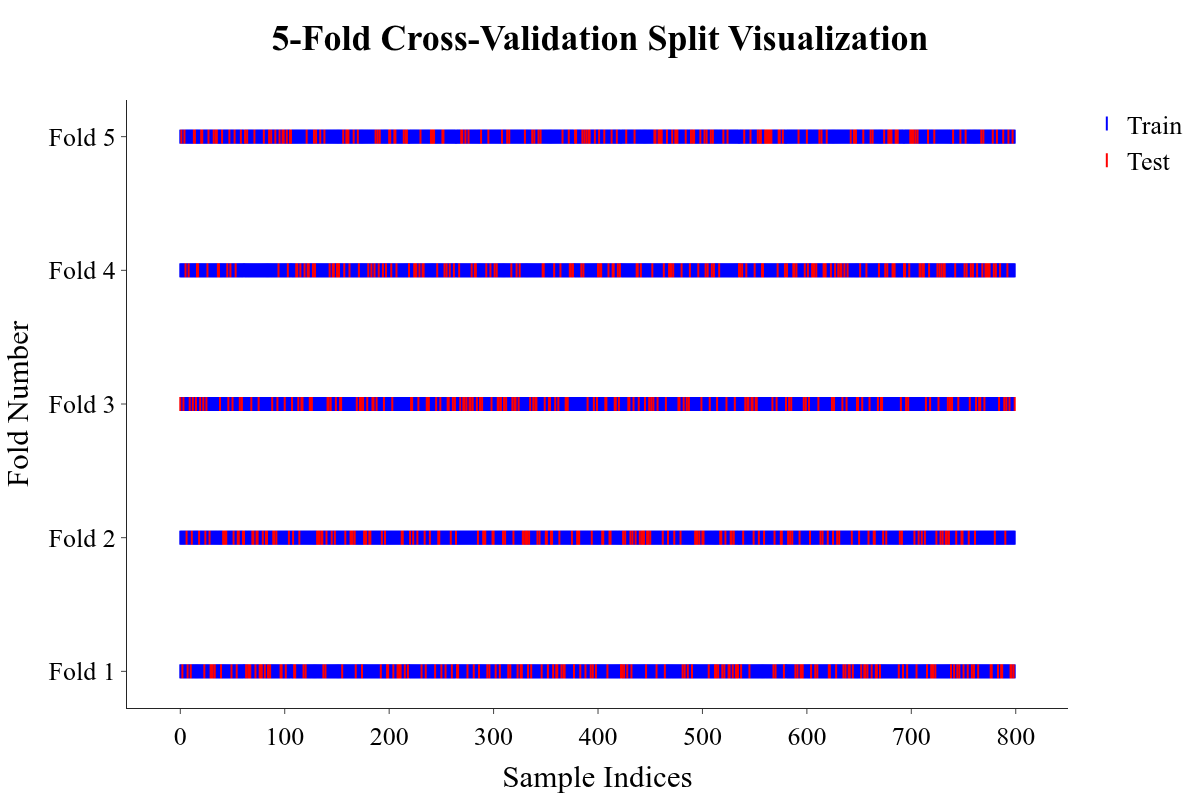

In [4]:
cv_basic = KFold(n_splits=5, shuffle=True, random_state=42)
other_plots.cross_validation_split_plot(
    X_class_synthetic,
    y_class_synthetic,
    cv_splitter=cv_basic,
    plot_title="5-Fold Cross-Validation Split Visualization",
)

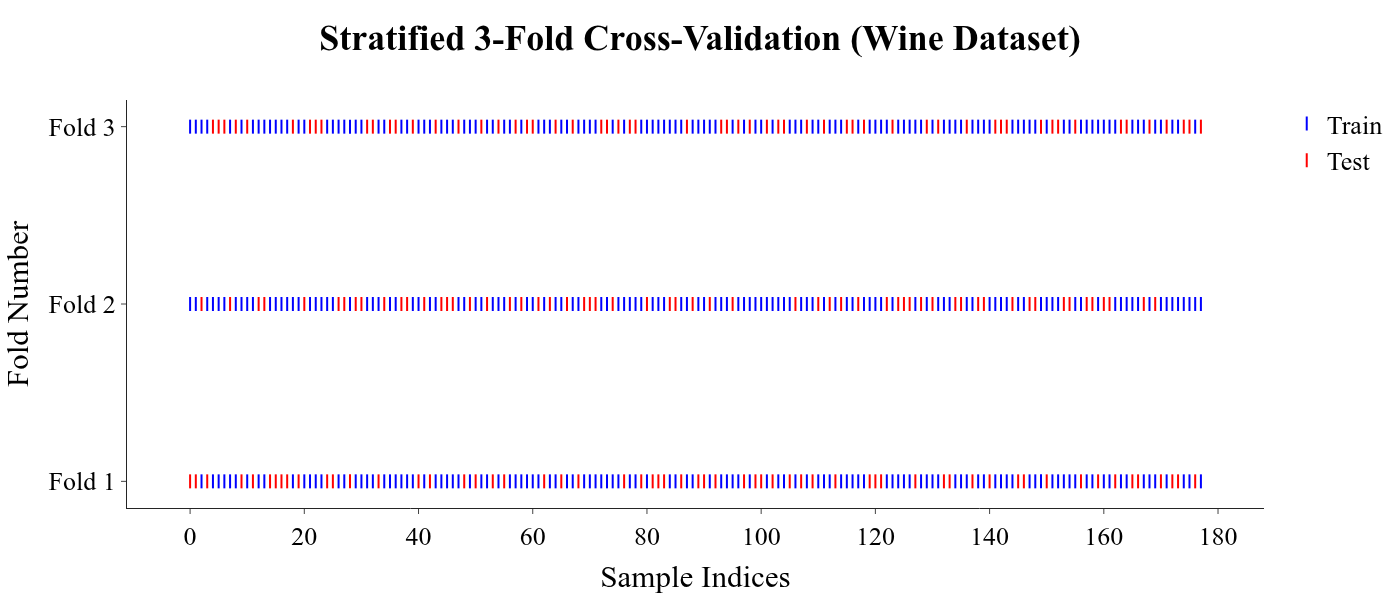

In [5]:
cv_stratified = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
other_plots.cross_validation_split_plot(
    X_wine,
    y_wine,
    cv_splitter=cv_stratified,
    plot_title="Stratified 3-Fold Cross-Validation (Wine Dataset)",
    width=1400,
    height=600,
)

## 2. ANOVA Comparison Plots

Compare feature values across different categories using box plots, useful for understanding feature distributions.

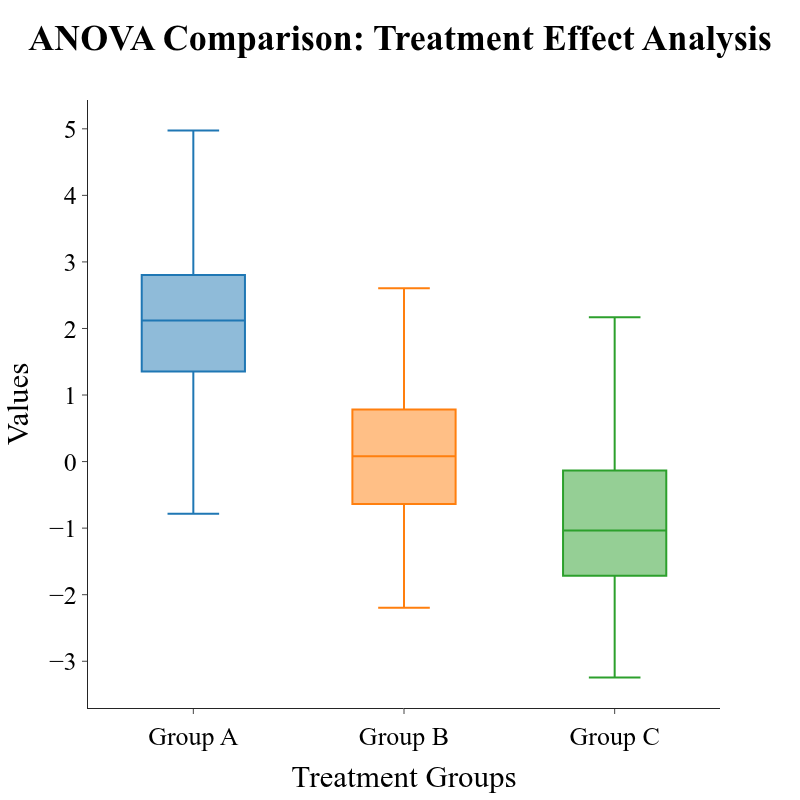

In [6]:
categories = np.random.choice(["Group A", "Group B", "Group C"], size=300)
values = np.random.normal(0, 1, 300) + np.where(
    categories == "Group A", 2, np.where(categories == "Group B", 0, -1)
)

other_plots.anova_comparison_plot(
    x_groups=categories,
    y_values=values,
    feature_name="Treatment Groups",
    plot_title="ANOVA Comparison: Treatment Effect Analysis",
)

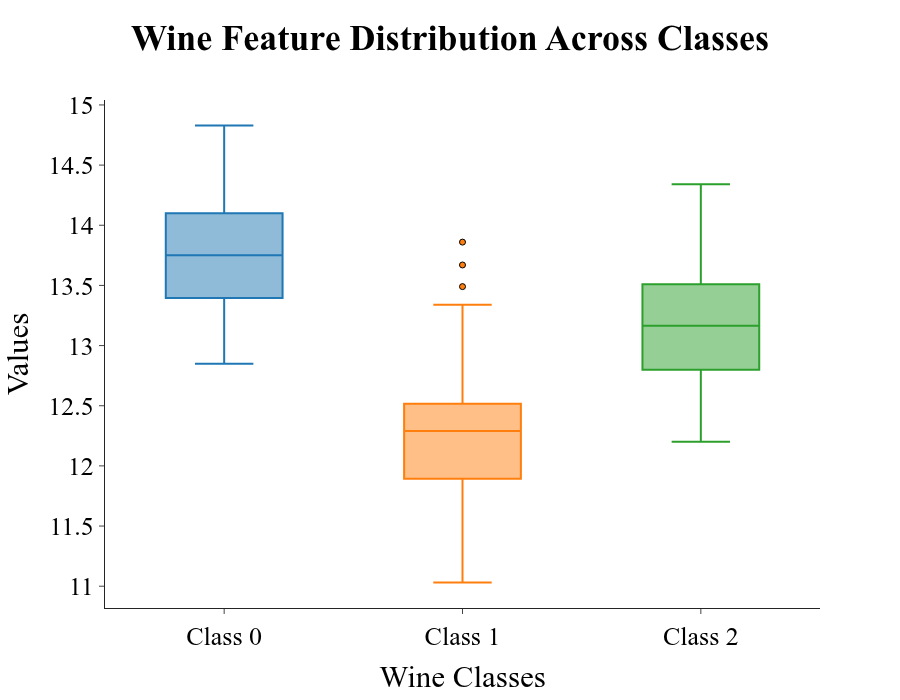

In [7]:
wine_feature = X_wine[:, 0]                                   
wine_classes = ["Class " + str(i) for i in y_wine]

other_plots.anova_comparison_plot(
    x_groups=wine_classes,
    y_values=wine_feature,
    feature_name="Wine Classes",
    plot_title="Wine Feature Distribution Across Classes",
    width=900,
    height=700,
)

## 3. Feature Ranking Comparison

Compare different feature ranking methods to identify the most important features using scatter plots.

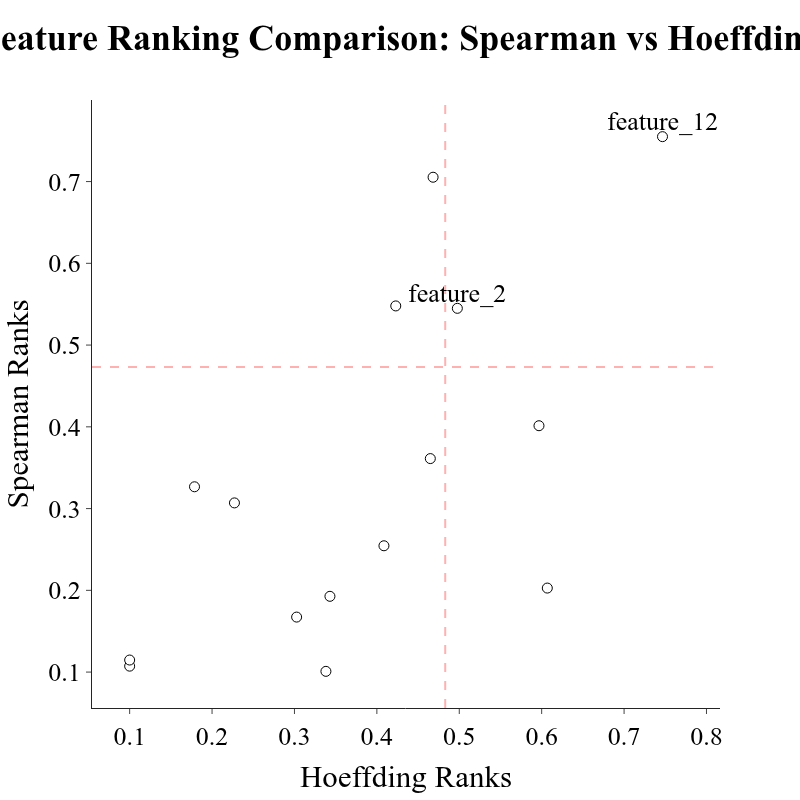

In [8]:
feature_names = [f"feature_{i}" for i in range(1, 16)]

spearman_ranks = {name: np.random.uniform(0.1, 0.9) for name in feature_names}

hoeffding_ranks = {}
for name in feature_names:
    base_score = spearman_ranks[name]
    noise = np.random.normal(0, 0.2)
    hoeffding_ranks[name] = max(0.1, min(0.9, base_score + noise))

other_plots.feature_ranking_scatter_plot(
    spearman_ranks=spearman_ranks,
    hoeffding_ranks=hoeffding_ranks,
    quantile=0.75,
    plot_title="Feature Ranking Comparison: Spearman vs Hoeffding",
)

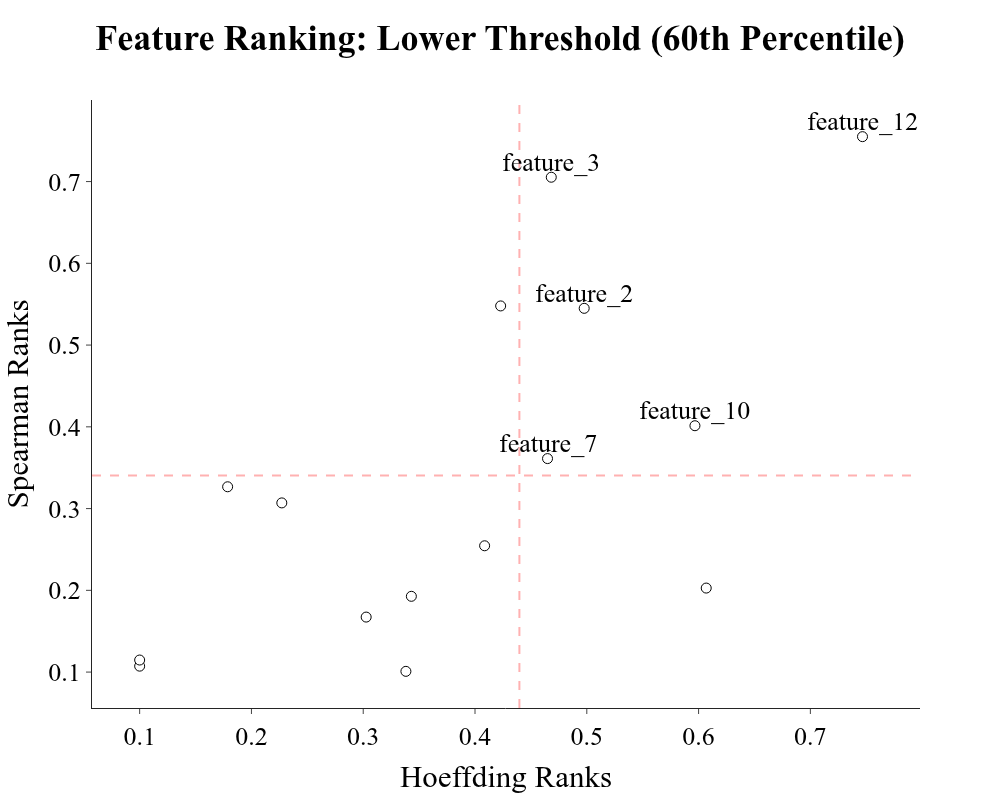

In [9]:
other_plots.feature_ranking_scatter_plot(
    spearman_ranks=spearman_ranks,
    hoeffding_ranks=hoeffding_ranks,
    quantile=0.6,
    plot_title="Feature Ranking: Lower Threshold (60th Percentile)",
    width=1000,
    height=800,
)

## 4. PCA Analysis Plots

Analyze principal component analysis results including explained variance and component visualization.

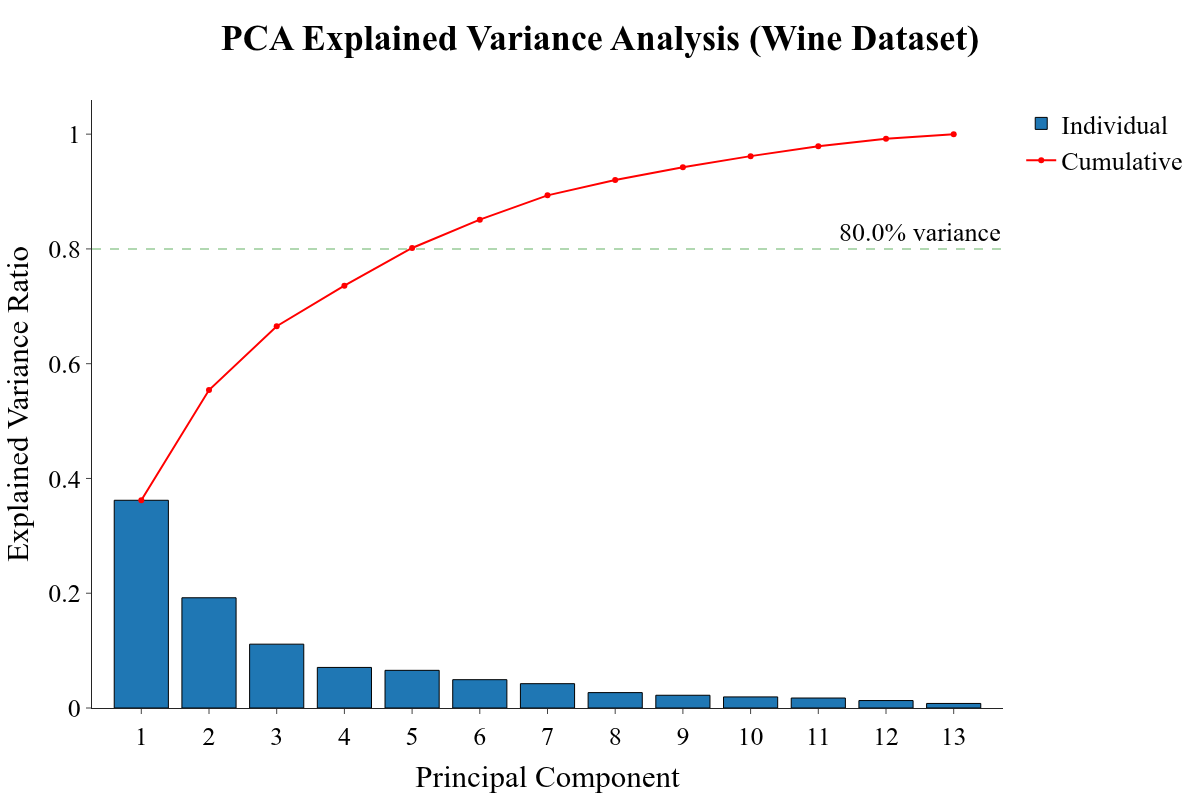

In [10]:
scaler = StandardScaler()
X_wine_scaled = scaler.fit_transform(X_wine)

pca_wine = PCA()
pca_wine.fit(X_wine_scaled)

other_plots.pca_explained_variance_plot(
    fitted_pca=pca_wine,
    plot_title="PCA Explained Variance Analysis (Wine Dataset)",
    variance_threshold=0.8,
)

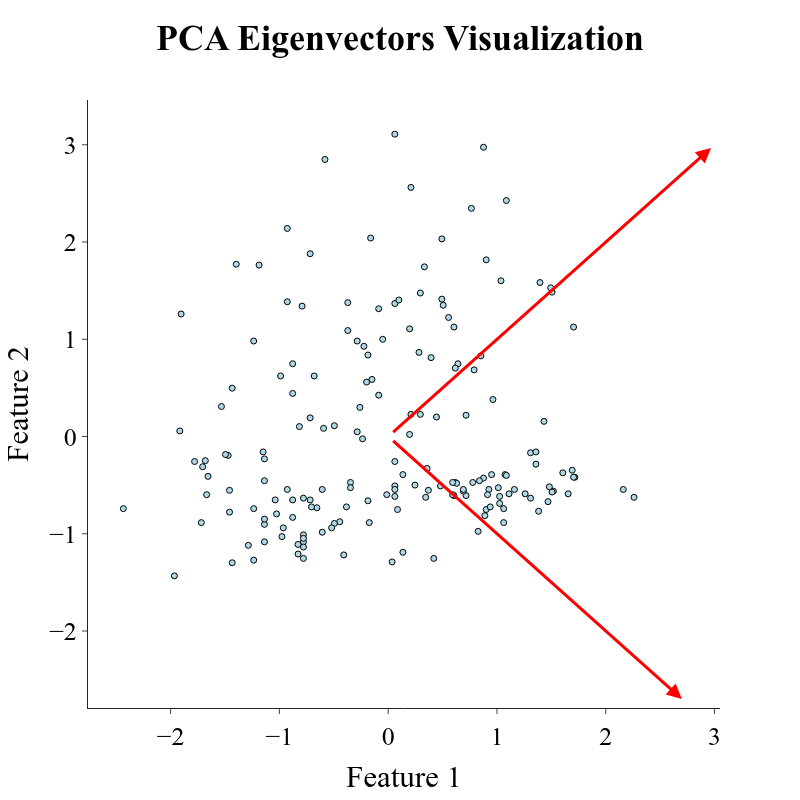

In [11]:
X_2d = X_wine_scaled[:, :2]                          
pca_2d = PCA(n_components=2)
pca_2d.fit(X_2d)

other_plots.pca_eigenvectors_plot(
    fitted_pca=pca_2d,
    feature1=X_2d[:, 0],
    feature2=X_2d[:, 1],
    plot_title="PCA Eigenvectors Visualization",
    vector_scale=4.0,
)

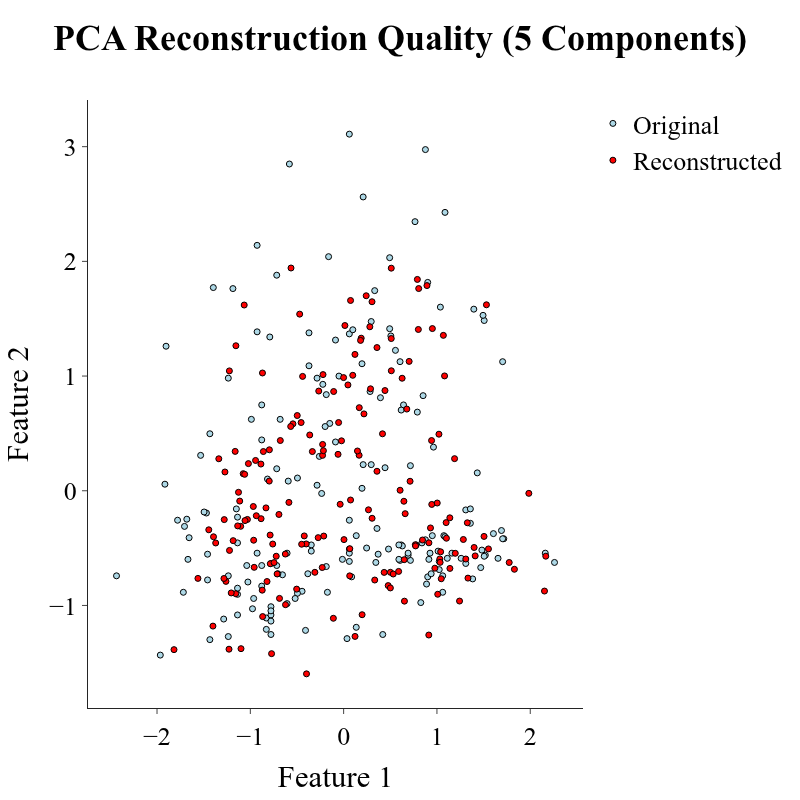

In [12]:
pca_reduced = PCA(n_components=5)                          
X_transformed = pca_reduced.fit_transform(X_wine_scaled)
X_reconstructed = pca_reduced.inverse_transform(X_transformed)

other_plots.pca_inverse_transform_plot(
    fitted_pca=pca_reduced,
    feature1=X_wine_scaled[:, 0],
    feature2=X_wine_scaled[:, 1],
    feature1_reconstructed=X_reconstructed[:, 0],
    feature2_reconstructed=X_reconstructed[:, 1],
    plot_title="PCA Reconstruction Quality (5 Components)",
)

## 5. Linear Discriminant Analysis (LDA)

Visualize LDA transformation results showing class separation in reduced dimensional space.

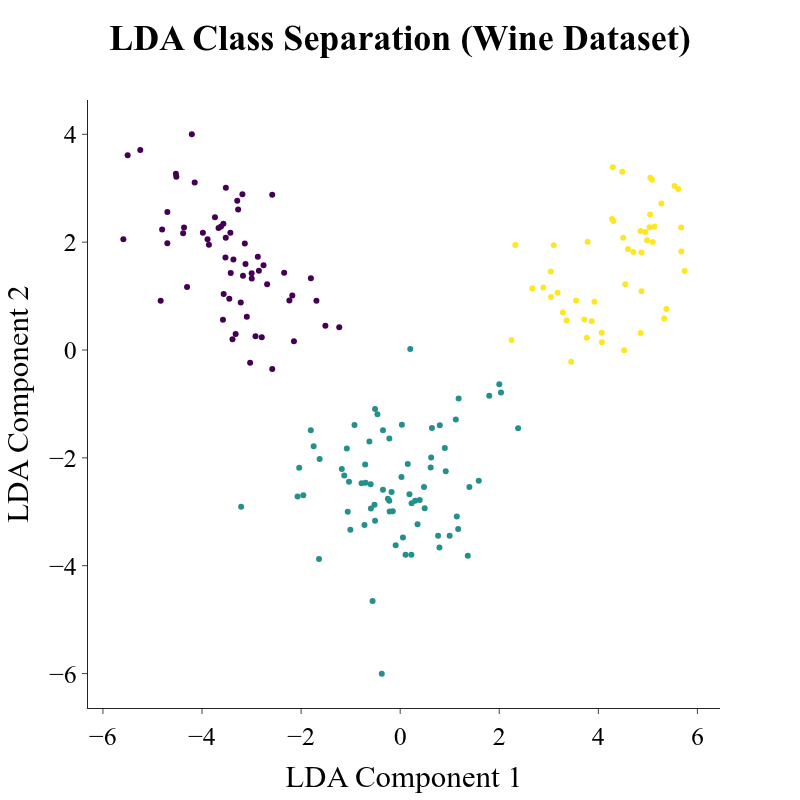

In [13]:
lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X_wine_scaled, y_wine)

other_plots.lda_separation_plot(
    x_transformed=X_lda, y_data=y_wine, plot_title="LDA Class Separation (Wine Dataset)"
)

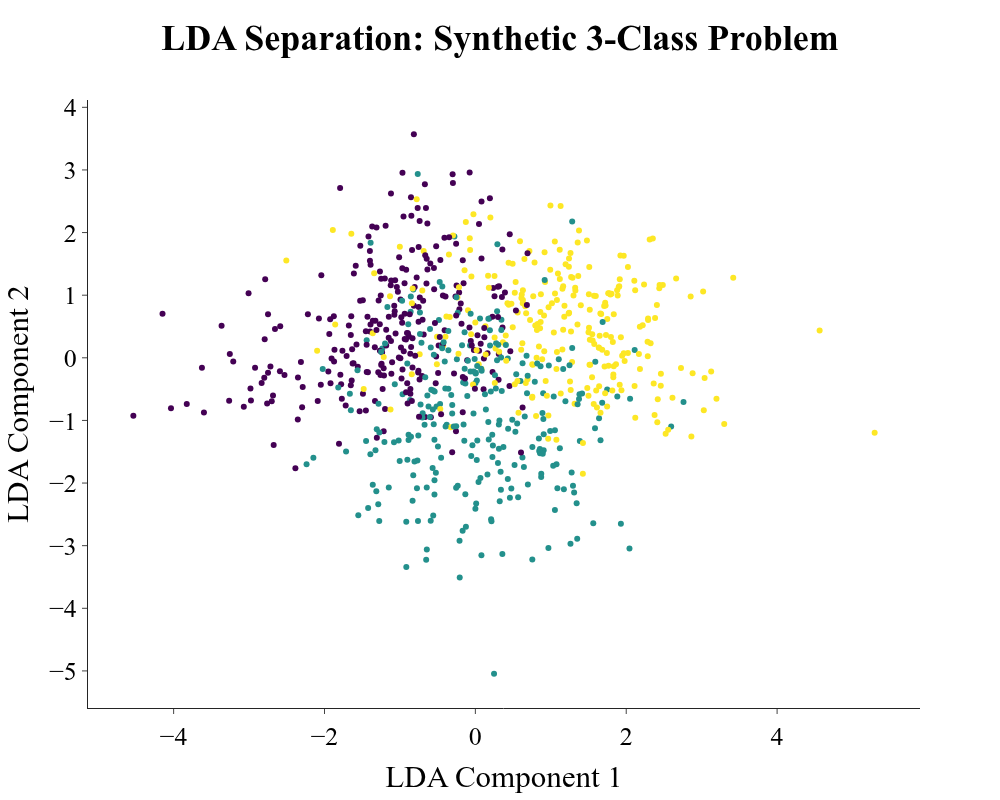

In [14]:
X_class_scaled = StandardScaler().fit_transform(X_class_synthetic)
lda_synthetic = LinearDiscriminantAnalysis(n_components=2)
X_lda_synthetic = lda_synthetic.fit_transform(X_class_scaled, y_class_synthetic)

other_plots.lda_separation_plot(
    x_transformed=X_lda_synthetic,
    y_data=y_class_synthetic,
    plot_title="LDA Separation: Synthetic 3-Class Problem",
    width=1000,
    height=800,
)

## 6. Clustering Analysis

Comprehensive clustering analysis including elbow method, silhouette analysis, and cluster visualization.

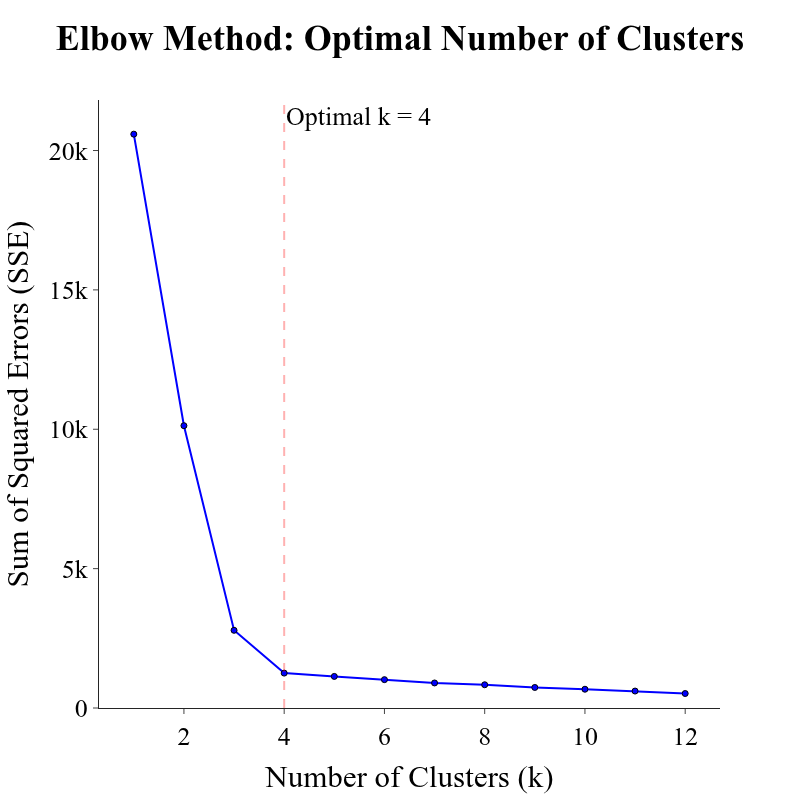

In [15]:
kmeans = KMeans(random_state=42)
other_plots.elbow_plot(
    data=X_clusters,
    clustering_algorithm=kmeans,
    max_clusters=12,
    plot_title="Elbow Method: Optimal Number of Clusters",
    show_optimal=True,
)

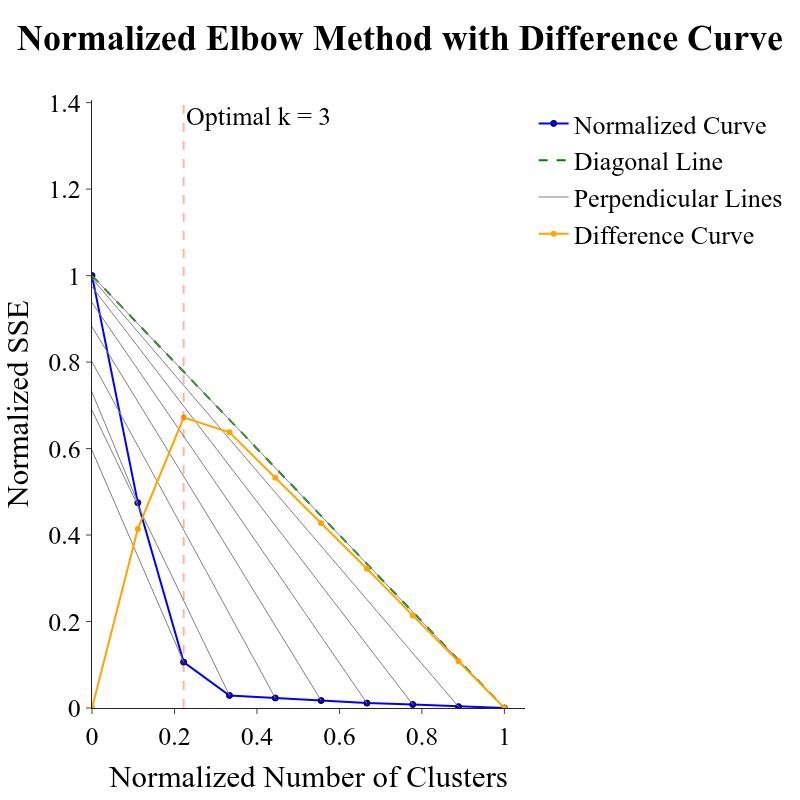

In [16]:
other_plots.normalized_elbow_plot(
    data=X_clusters,
    clustering_algorithm=kmeans,
    max_clusters=10,
    plot_title="Normalized Elbow Method with Difference Curve",
    show_difference_curve=True,
    show_perpendicular=True,
)

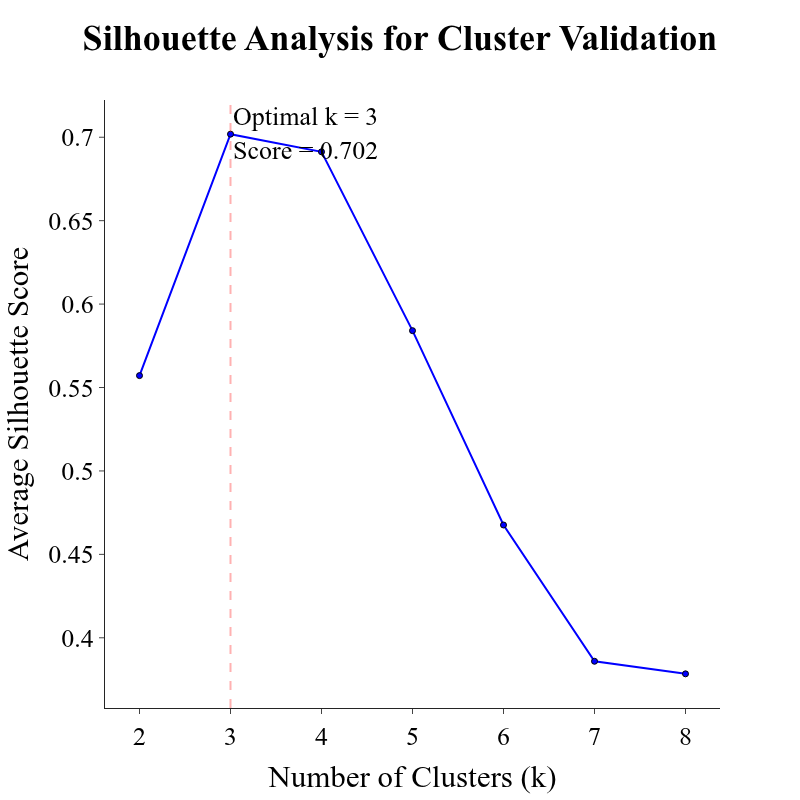

In [17]:
other_plots.silhouette_analysis_plot(
    data=X_clusters,
    clustering_algorithm=kmeans,
    max_clusters=8,
    plot_title="Silhouette Analysis for Cluster Validation",
)

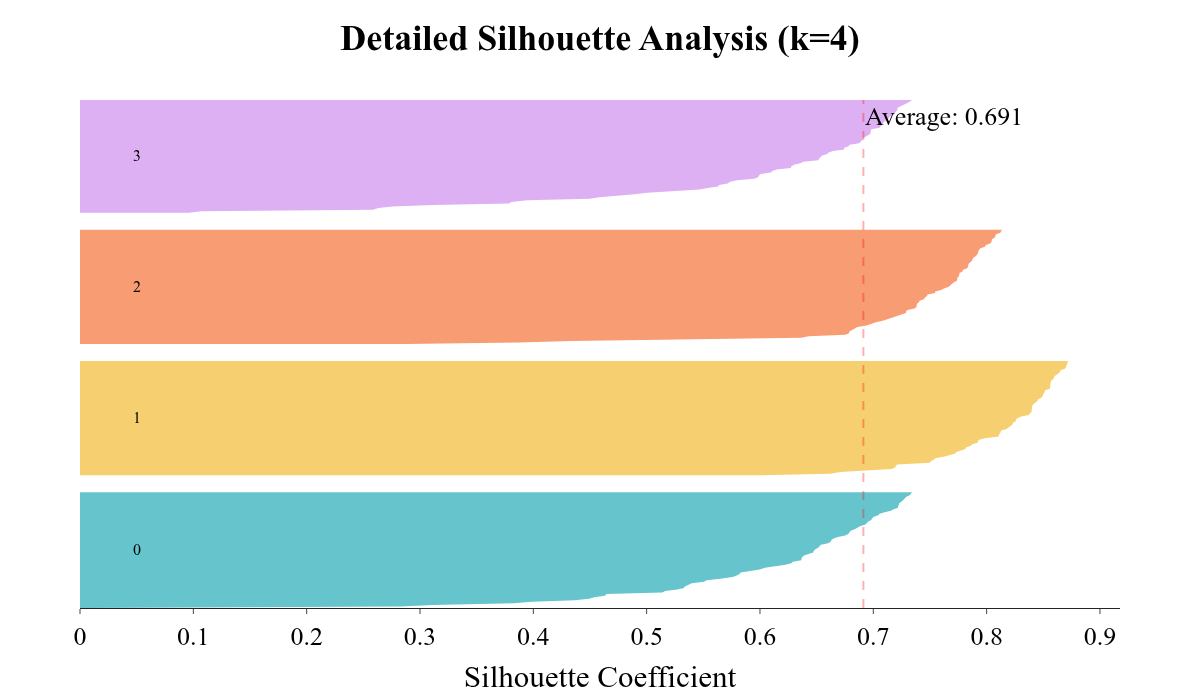

In [18]:
other_plots.silhouette_detailed_plot(
    data=X_clusters,
    clustering_algorithm=kmeans,
    n_clusters=4,
    plot_title="Detailed Silhouette Analysis (k=4)",
    width=1200,
    height=700,
)

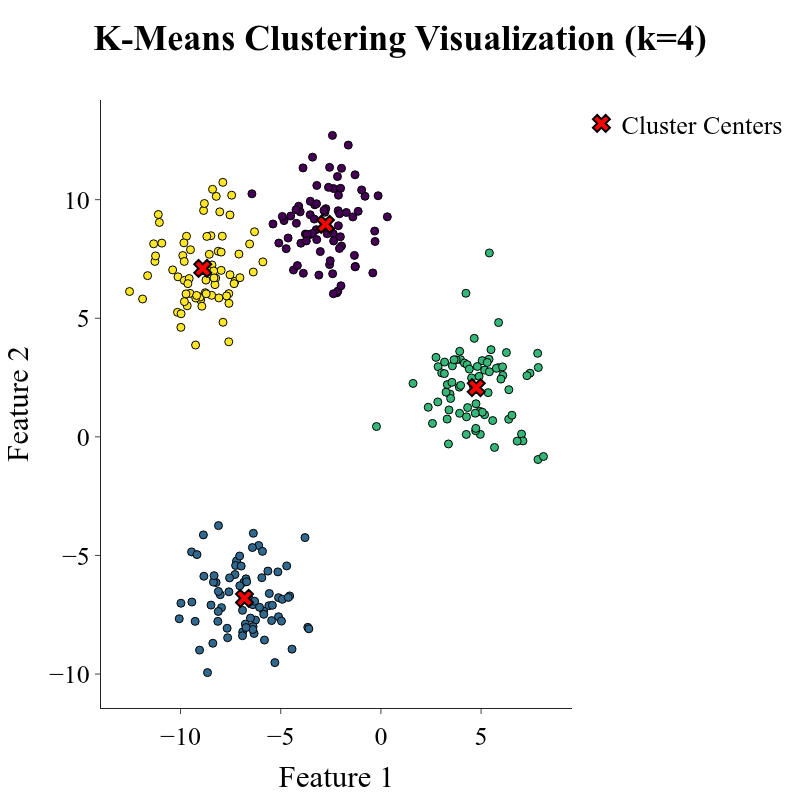

In [19]:
kmeans_fitted = KMeans(n_clusters=4, random_state=42)
kmeans_fitted.fit(X_clusters)

other_plots.cluster_visualization_plot(
    data=X_clusters,
    fitted_model=kmeans_fitted,
    plot_title="K-Means Clustering Visualization (k=4)",
    show_centers=True,
)

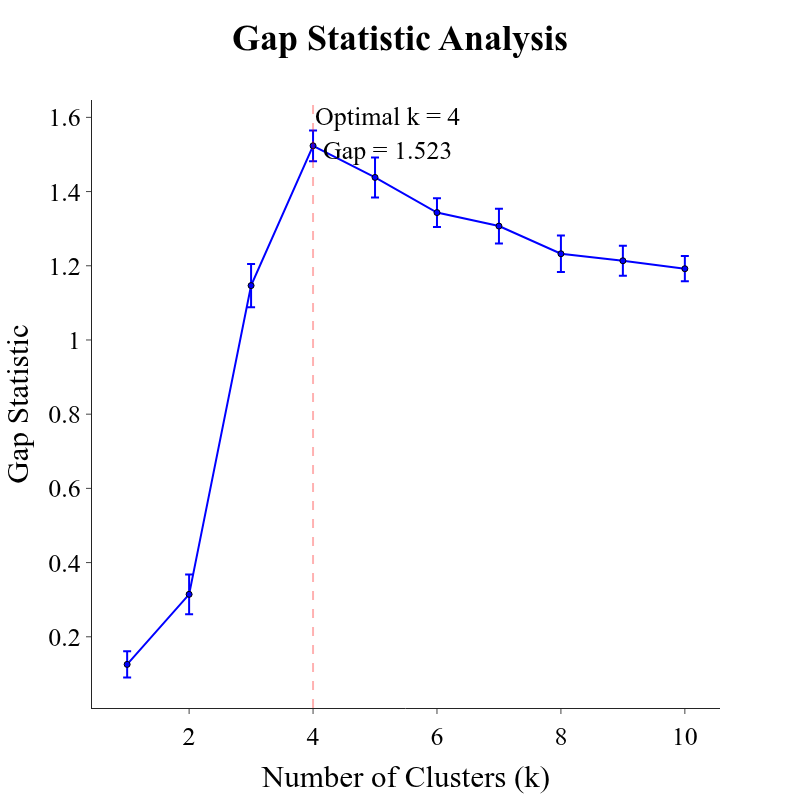

In [20]:
other_plots.gap_statistic_plot(
    data=X_clusters,
    clustering_algorithm=kmeans,
    max_clusters=10,
    n_reference_datasets=20,
    plot_title="Gap Statistic Analysis",
)

## 7. DBSCAN Analysis

Analyze DBSCAN clustering parameters using k-distance plots.

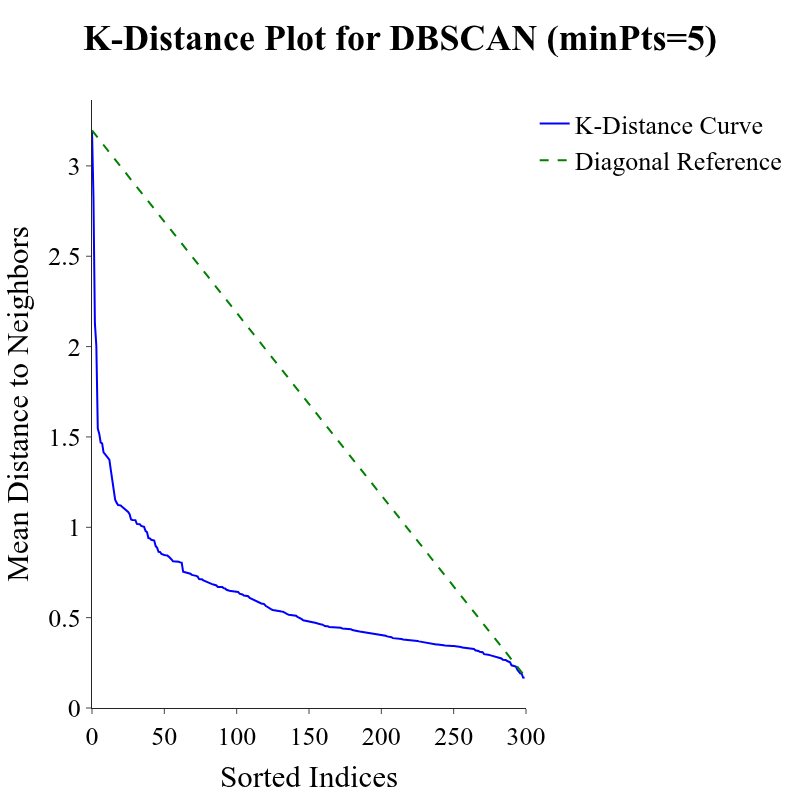

In [21]:
other_plots.k_distance_plot(
    data=X_clusters, min_points=5, plot_title="K-Distance Plot for DBSCAN (minPts=5)"
)

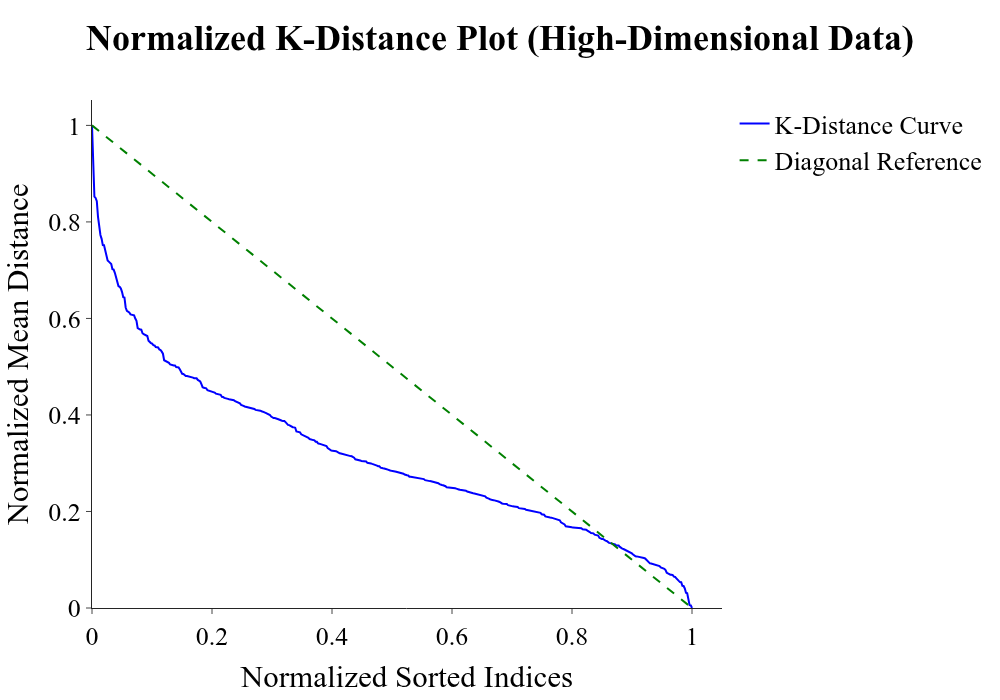

In [22]:
other_plots.k_distance_plot(
    data=X_clusters_hd,
    min_points=10,
    plot_title="Normalized K-Distance Plot (High-Dimensional Data)",
    normalized=True,
    width=1000,
    height=700,
)

## 8. Hierarchical Clustering

Visualize hierarchical clustering results using dendrograms.

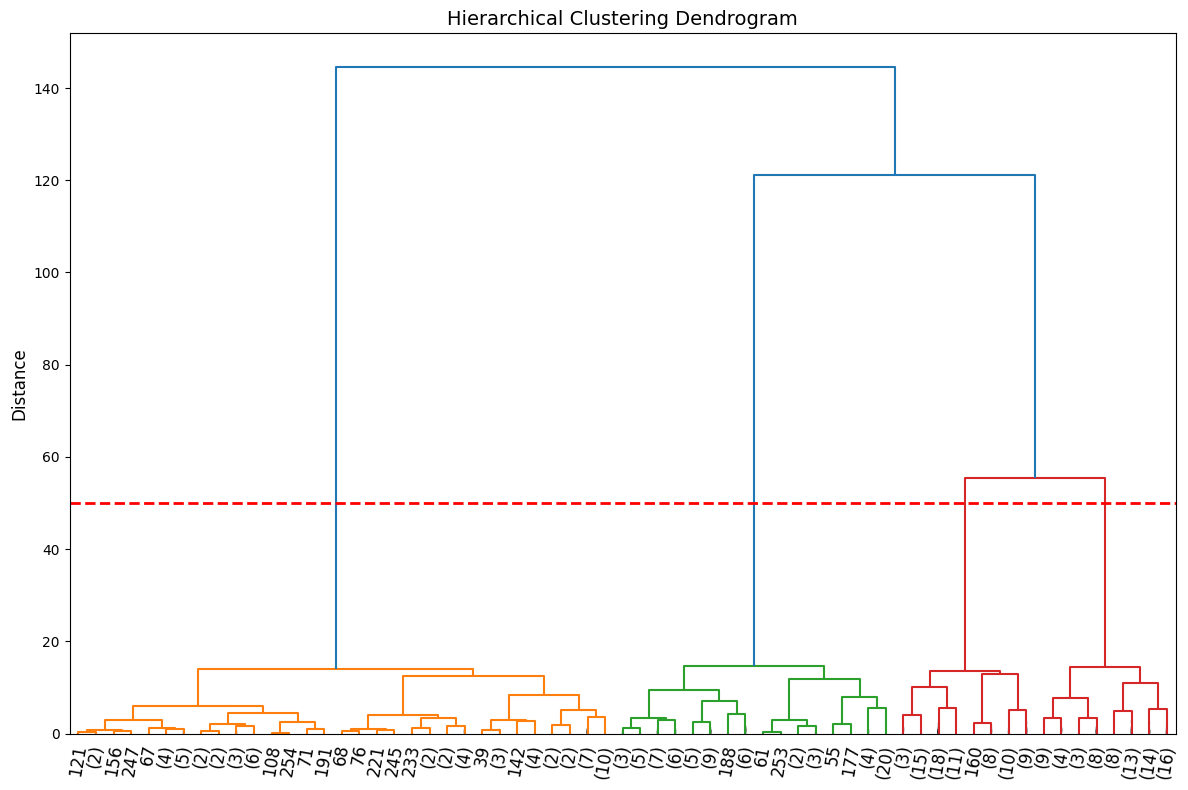

In [23]:
linkage_matrix = linkage(X_clusters, method="ward")

other_plots.dendrogram_plot(
    linkage_matrix=linkage_matrix,
    plot_title="Hierarchical Clustering Dendrogram",
    truncate_mode="level",
    p=5,
    hline_level=50,
)

## 9. Anomaly Detection

Visualize different anomaly detection methods including Mahalanobis distance, Isolation Forest, and Local Outlier Factor.

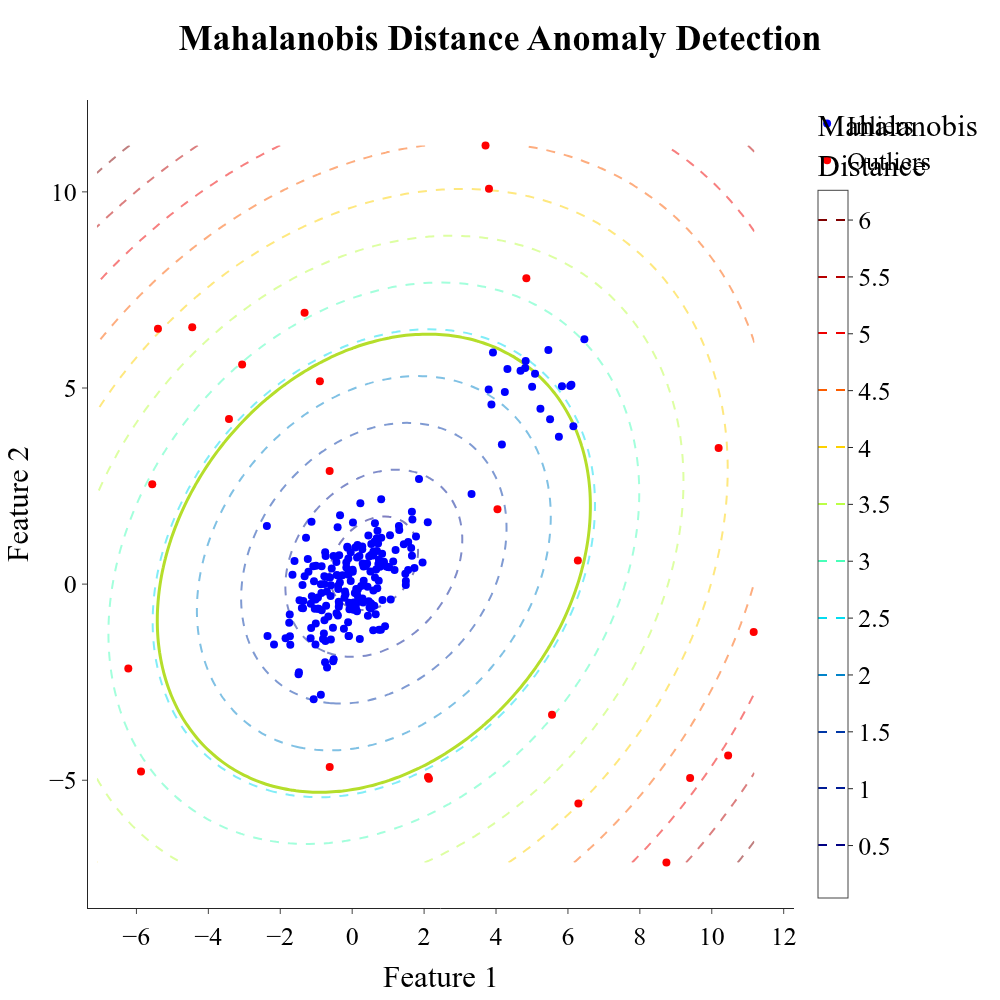

In [24]:
other_plots.mahalanobis_anomaly_plot(
    x_data=X_anomaly_with_outliers,
    n_outliers=25,
    alpha=0.05,
    plot_title="Mahalanobis Distance Anomaly Detection",
)

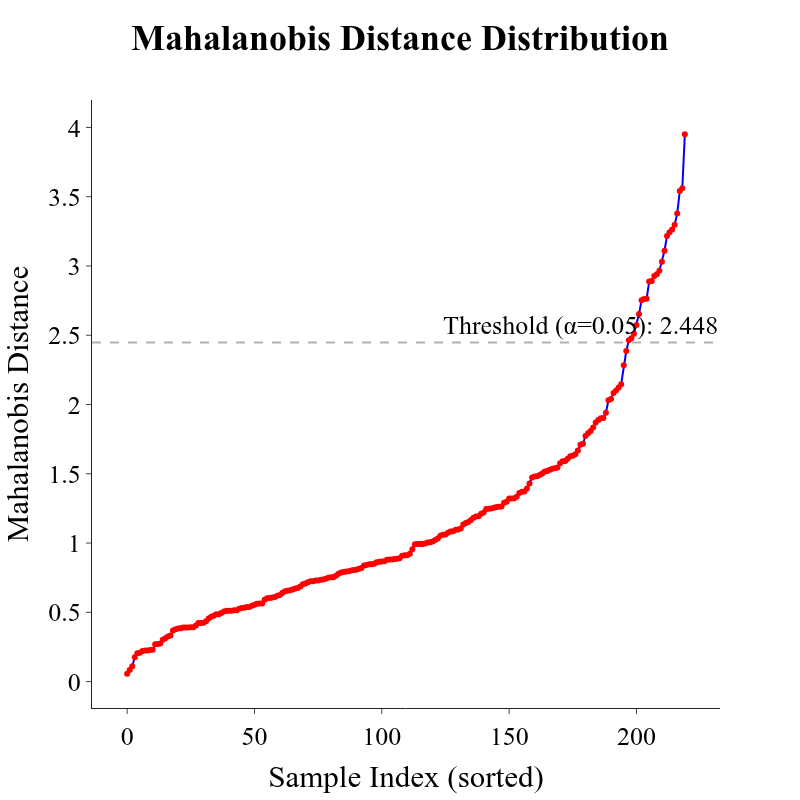

In [25]:
other_plots.mahalanobis_distance_plot(
    x_data=X_anomaly_with_outliers, alpha=0.05, plot_title="Mahalanobis Distance Distribution"
)

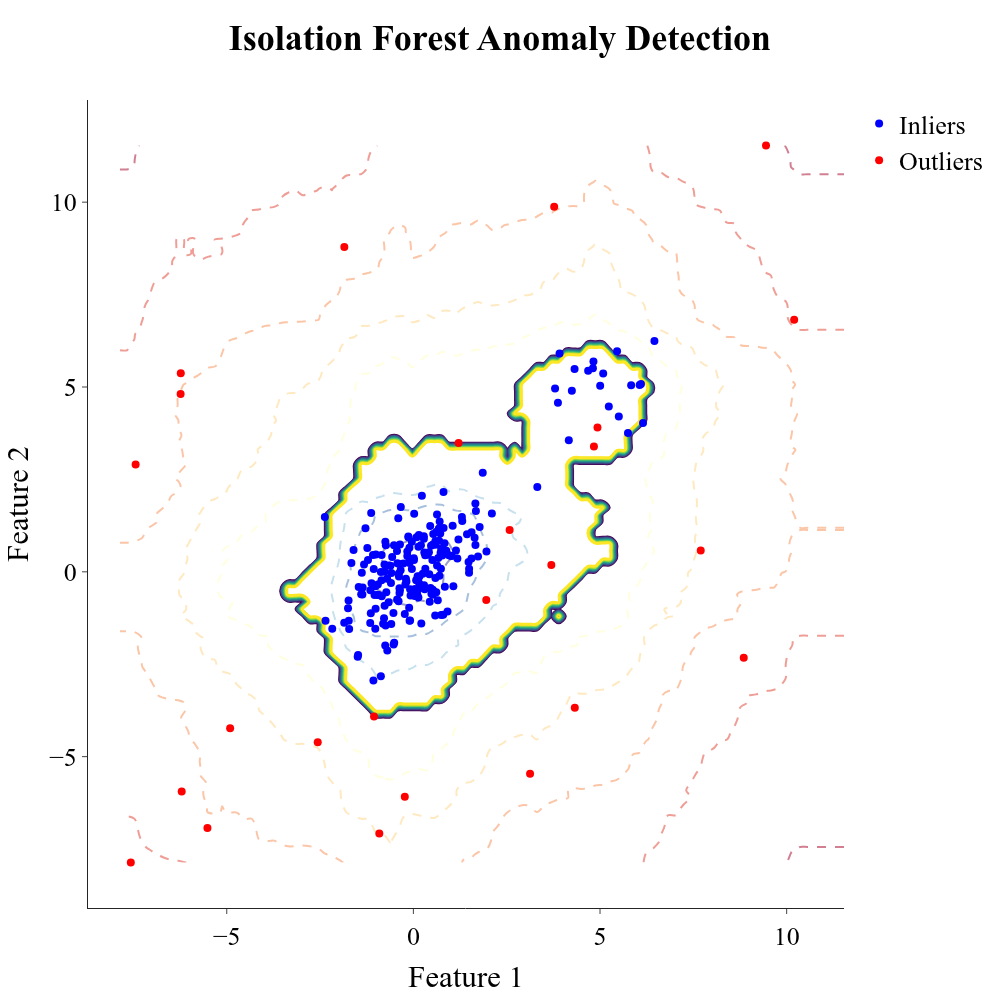

In [26]:
other_plots.isolation_forest_plot(
    x_data=X_anomaly_with_outliers,
    n_outliers=25,
    contamination=0.1,
    plot_title="Isolation Forest Anomaly Detection",
    random_state=42,
)

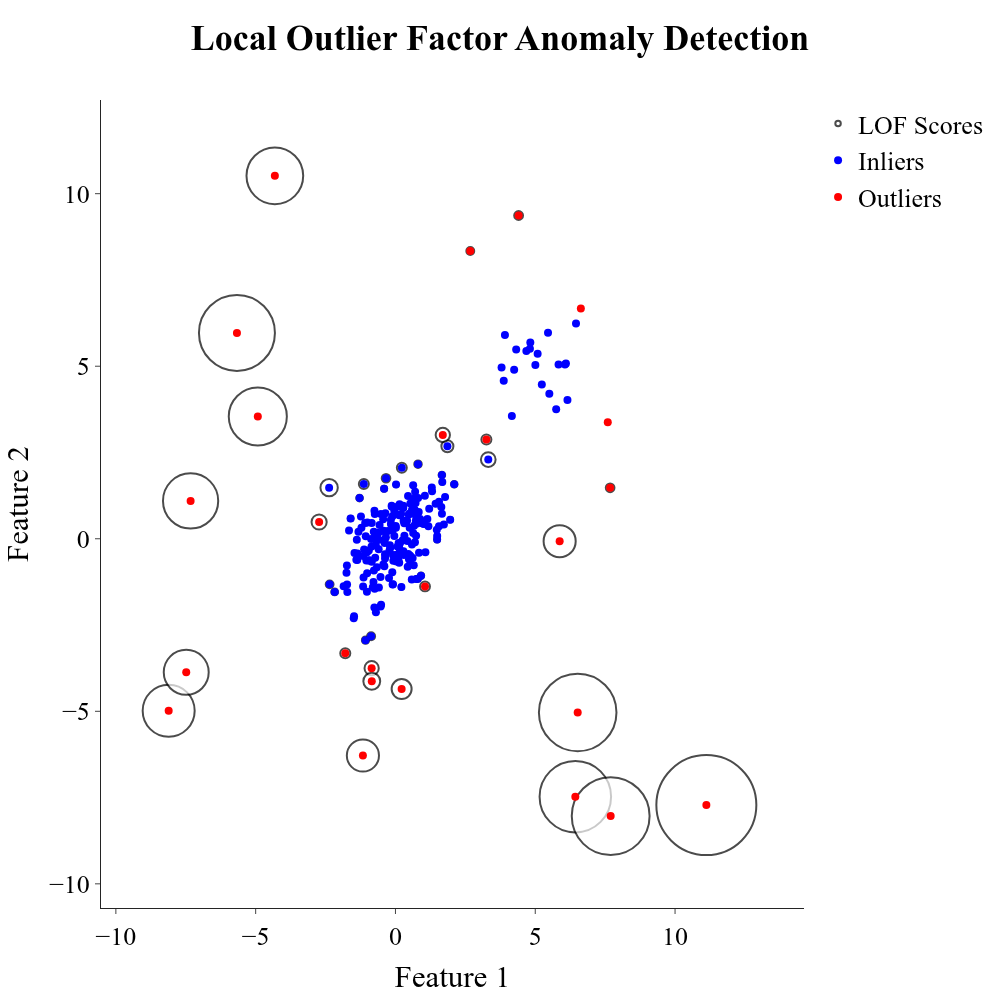

In [27]:
other_plots.local_outlier_factor_plot(
    x_data=X_anomaly_with_outliers,
    n_outliers=25,
    contamination=0.1,
    n_neighbors=20,
    plot_title="Local Outlier Factor Anomaly Detection",
)

## 10. Factor Analysis

Analyze factor structures using scree plots to determine optimal number of factors.

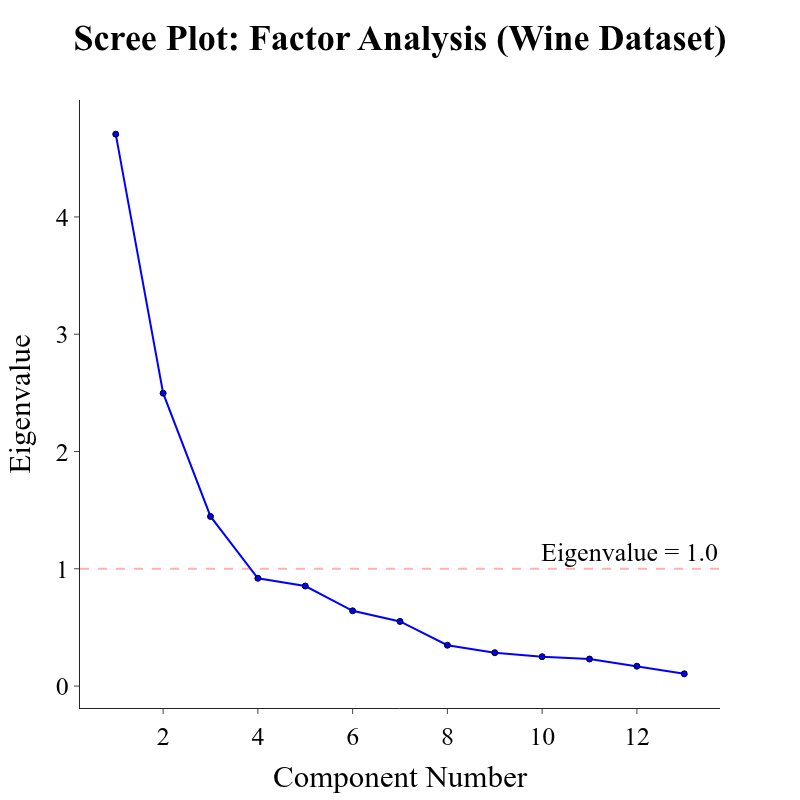

In [28]:
X_wine_for_fa = StandardScaler().fit_transform(X_wine)
fa = FactorAnalysis(n_components=10, random_state=42)
fa.fit(X_wine_for_fa)

other_plots.scree_plot(
    fitted_fa=fa, plot_title="Scree Plot: Factor Analysis (Wine Dataset)", eigenvalue_threshold=1.0
)

## 11. Feature Selection Visualization

Visualize feature selection progress and metric changes as features are removed.

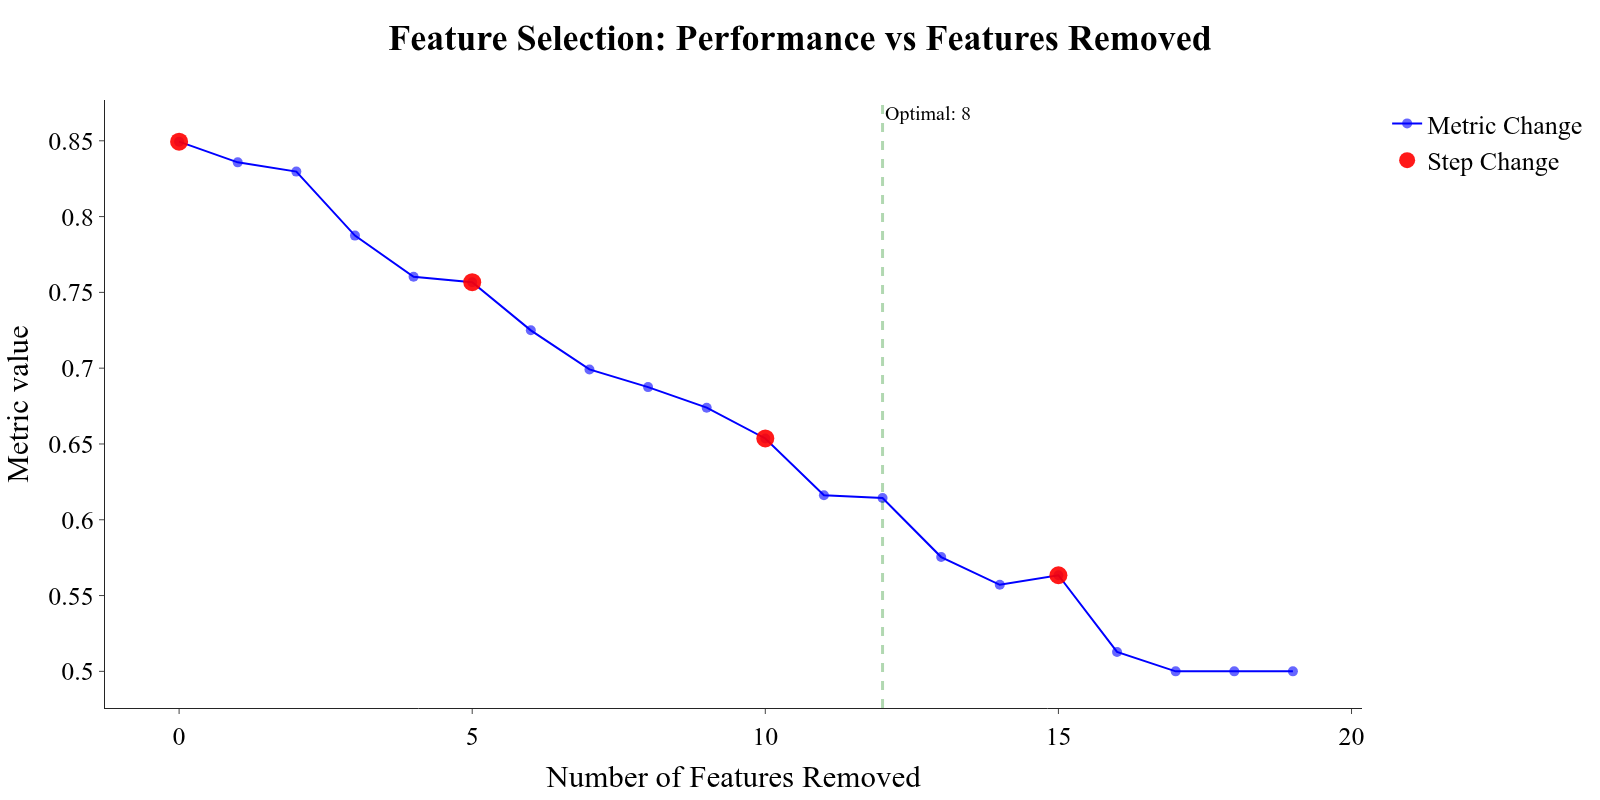

In [29]:
n_features = 20
history_data = []

for i in range(n_features):
    base_score = 0.85 - (i * 0.02) + np.random.normal(0, 0.01)
    history_data.append(
        {
            "n_features_removed": i,
            "metric_value": max(0.5, base_score),
            "step": i // 5,                    
        }
    )

history_df = pd.DataFrame(history_data)

other_plots.plot_metric_change_vs_features_removed(
    history=history_df,
    optimal_n_features=8,
    plot_title="Feature Selection: Performance vs Features Removed",
)

## 12. Advanced Clustering Analysis

Additional clustering analysis methods including difference curves and advanced metrics.

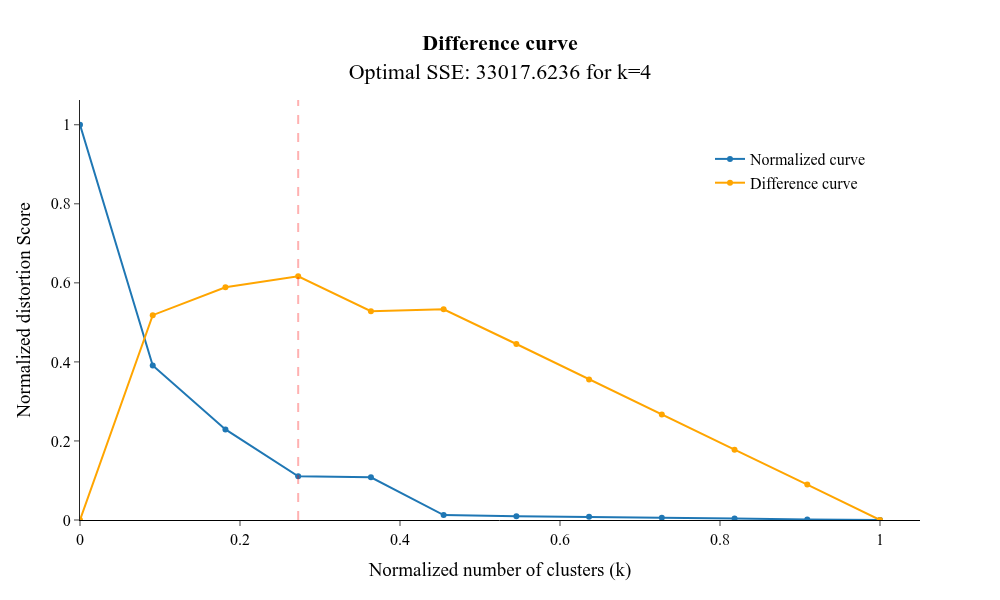

In [30]:
other_plots.difference_curve(
    data=X_clusters_hd, algorithm_instance=kmeans, max_clusters=12, width=1000, height=600
)